# Gravitational-Wave Sky Localization by Triangulation

### A Google Colab tutorial: from arrival-time delays to rings on the sky

In this notebook we build gravitational-wave (GW) sky localization from simple geometry.

By the end, you will be able to:

1. derive
   $
   \Delta t_{ij}=-\frac{\mathbf B_{ij}\cdot\hat{\mathbf n}}{c},$
2. understand why **two detectors give a ring (annulus) on the sky**,
3. see how timing uncertainty gives the ring a finite width,
4. add a third detector and watch two timing annuli intersect,
5. understand the **mirror degeneracy** of a three-detector timing network,
6. calculate an approximate 90% follow-up area,
7. see how SNR, bandwidth, baseline length, and network geometry affect localization.

This is deliberately a geometric tutorial, not a full Bayesian localization code such as BAYESTAR.


## 1. The time-delay equation

Let $\hat{\mathbf n}$ point from Earth **toward the source**. A plane GW can be written schematically as

$
h\!\left(t+\frac{\hat{\mathbf n}\cdot\mathbf r}{c}\right).
$

The same point on the waveform reaches detectors \(i\) and \(j\) when

$
t_i+\frac{\hat{\mathbf n}\cdot\mathbf r_i}{c}
=
t_j+\frac{\hat{\mathbf n}\cdot\mathbf r_j}{c}.
$

Therefore

$
t_j-t_i
=
-\frac{\hat{\mathbf n}\cdot(\mathbf r_j-\mathbf r_i)}{c}.
$

Define the baseline

$
\mathbf B_{ij}=\mathbf r_j-\mathbf r_i.
$

Then

$
\boxed{
\Delta t_{ij}
=
-\frac{\mathbf B_{ij}\cdot\hat{\mathbf n}}{c}.
}
$

If $\theta$ is the angle between the baseline and source direction,

$
|\Delta t_{ij}|=\frac{B_{ij}}{c}|\cos\theta|.
$

For $B\simeq4000\,\mathrm{km}$,

$
\frac{B}{c}\simeq13\,\mathrm{ms}.
$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

c = 299_792.458  # km/s

plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["font.size"] = 12


## 2. Representing the sky

We describe a sky direction by right ascension $\alpha$ and declination $\delta$:

$
\hat{\mathbf n}
=
(\cos\delta\cos\alpha,\,
 \cos\delta\sin\alpha,\,
 \sin\delta).
$

For pedagogy, we work in a fixed Earth-centered Cartesian frame and label its spherical angles as RA/Dec.

> **Simplification:** a real analysis uses the event GPS time to transform Earth-fixed detector positions into celestial coordinates. Here the orientation is fixed so that the triangulation geometry is easy to see.


In [ ]:
def unit_vector_from_radec(ra_deg, dec_deg):
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    return np.stack([
        np.cos(dec) * np.cos(ra),
        np.cos(dec) * np.sin(ra),
        np.sin(dec)
    ], axis=-1)

def time_delay(baseline_km, n_hat):
    # n_hat points from Earth toward the source.
    return -np.sum(np.asarray(baseline_km) * n_hat, axis=-1) / c

# Sky grid
ra = np.linspace(-180, 180, 721)
dec = np.linspace(-90, 90, 361)
RA, DEC = np.meshgrid(ra, dec)
N = unit_vector_from_radec(RA, DEC)

print("Sky grid:", RA.shape)


Sky grid: (361, 721)


## 3. Two detectors: why a ring?

Choose the first baseline along the \(z\)-axis,

$
\mathbf B_1=(0,0,B).
$

Then

$
\Delta t_1=-\frac{B}{c}\sin\delta.
$

A measured delay fixes one angular coordinate but leaves the other unconstrained. On the sphere, all directions satisfying the same dot product form a **ring**.

We inject a source and ask which other sky positions give the same delay.


In [ ]:
B1 = np.array([0.0, 0.0, 3000.0])  # km, separation of of HL

true_ra = 45.0
true_dec = 30.0
n_true = unit_vector_from_radec(true_ra, true_dec)

dt1_obs = time_delay(B1, n_true)

print(f"True source: RA={true_ra:.1f} deg, Dec={true_dec:.1f} deg")
print(f"Observed delay = {1e3*dt1_obs:.3f} ms")
print(f"Sanity check: Maximum |delay| = {1e3*np.linalg.norm(B1)/c:.3f} ms")


True source: RA=45.0 deg, Dec=30.0 deg
Observed delay = -5.003 ms
Sanity check: Maximum |delay| = 10.007 ms


### Finite timing precision makes an annulus

Matched filtering estimates the arrival time with finite uncertainty. A useful scaling is

$
\sigma_t\sim\frac{1}{2\pi\rho\sigma_f},
$

where $\rho$ is SNR and $\sigma_f$ is the effective signal bandwidth.

Higher SNR or more broadband signal --> smaller uncertainty in arrival times --> smaller ring thickness


So instead of an infinitely thin ring we get an annulus:

$
|\Delta t_{\rm pred}-\Delta t_{\rm obs}|
\lesssim \sigma_{\Delta t}.
$

We start with an illustrative $0.30\,\mathrm{ms}$ timing uncertainty.


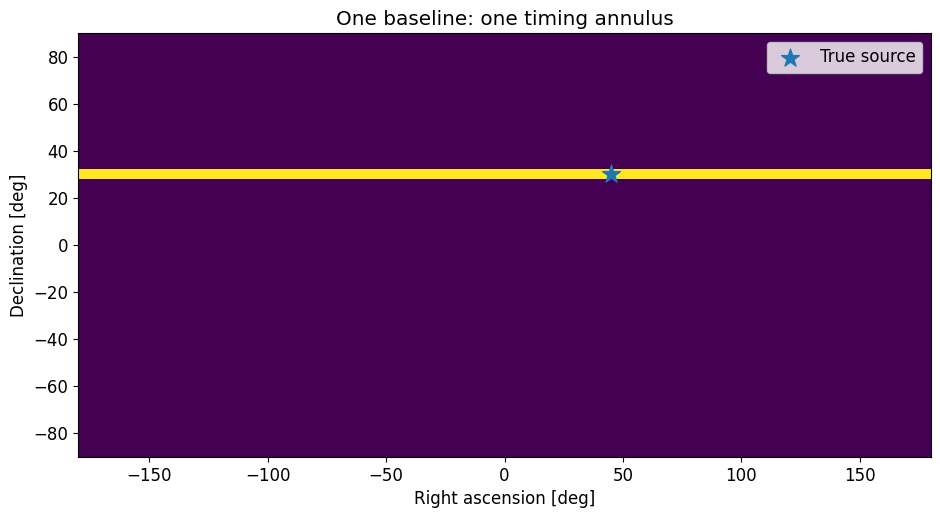

In [ ]:
sigma_dt = 0.30e-3  # seconds

dt1_sky = time_delay(B1, N)
resid1 = dt1_sky - dt1_obs
allowed1 = np.abs(resid1) <= sigma_dt

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.imshow(allowed1.astype(float), origin="lower",
          extent=[-180, 180, -90, 90],
          aspect="auto", interpolation="nearest")
ax.scatter(true_ra, true_dec, marker="*", s=180, label="True source")
ax.set_xlabel("Right ascension [deg]")
ax.set_ylabel("Declination [deg]")
ax.set_title("One baseline: one timing annulus")
ax.legend()
plt.show()


The horizontal band is the ring viewed in this RA/Dec projection.

The essential counting is

$
\boxed{
\text{one independent delay}
\Rightarrow
\text{one angular constraint}.
}
$

In coordinates with the baseline as the polar axis,

$
\Delta t=\frac{B}{c}\cos\theta
$

fixes $\theta$, while $\phi$ remains unconstrained.


## 4. Add a third detector: a second independent baseline

Now introduce a second baseline in a different direction,

$
\mathbf B_2=(B_2,0,0).
$

Its delay is

$
\Delta t_2
=
-\frac{B_2}{c}\cos\delta\cos\alpha.
$

This contains information about the second sky coordinate.

Each delay separately gives an annulus. Their intersection gives much smaller allowed regions.


In [ ]:
B2 = np.array([8520.0, 0.0, 0.0])  # km, for LV separation

dt2_obs = time_delay(B2, n_true)
dt2_sky = time_delay(B2, N)
resid2 = dt2_sky - dt2_obs

allowed2 = np.abs(resid2) <= sigma_dt
allowed_both = allowed1 & allowed2

print(f"Baseline 2 delay = {1e3*dt2_obs:.3f} ms")


Baseline 2 delay = -17.403 ms


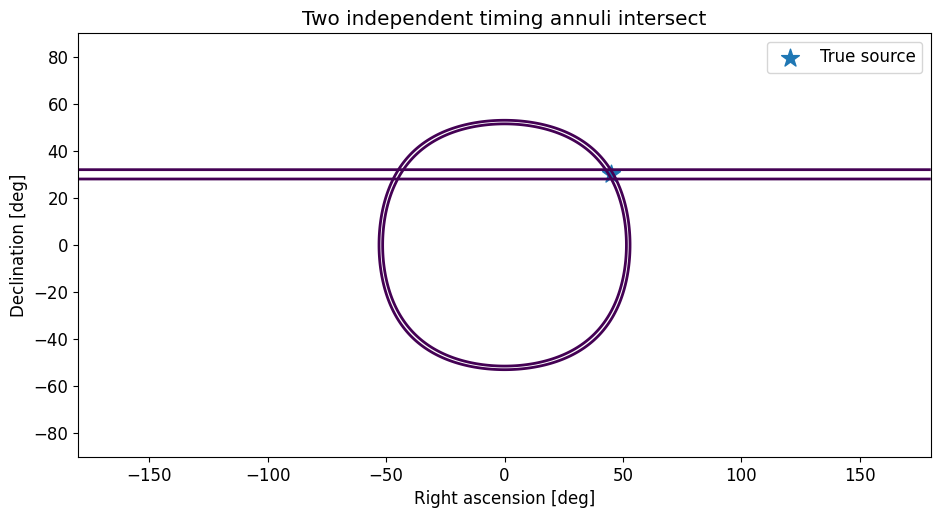

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.contour(RA, DEC, np.abs(resid1)/sigma_dt, levels=[1.0], linewidths=2)
ax.contour(RA, DEC, np.abs(resid2)/sigma_dt, levels=[1.0], linewidths=2)

ax.scatter(true_ra, true_dec, marker="*", s=180, label="True source")
ax.set_xlabel("Right ascension [deg]")
ax.set_ylabel("Declination [deg]")
ax.set_title("Two independent timing annuli intersect")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.legend()
plt.show()


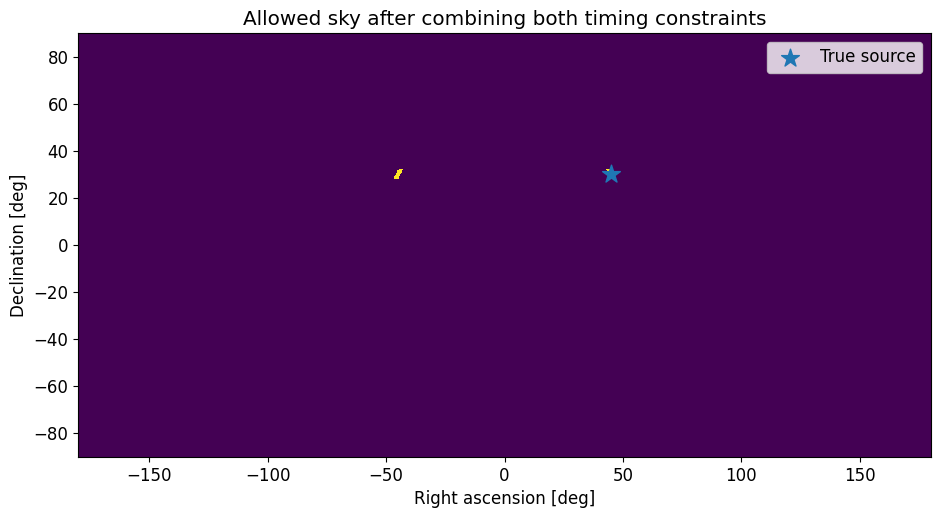

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.imshow(allowed_both.astype(float), origin="lower",
          extent=[-180, 180, -90, 90],
          aspect="auto", interpolation="nearest")
ax.scatter(true_ra, true_dec, marker="*", s=180, label="True source")
ax.set_xlabel("Right ascension [deg]")
ax.set_ylabel("Declination [deg]")
ax.set_title("Allowed sky after combining both timing constraints")
ax.legend()
plt.show()


## 5. Why are there two intersection patches?

Our two baselines lie in the $x-z$ plane.

Timing measures

$
\mathbf B_1\cdot\hat{\mathbf n},
\qquad
\mathbf B_2\cdot\hat{\mathbf n}.
$

Reflect the source across the plane containing the detector network:

$
n_y\rightarrow -n_y.
$

Both dot products remain unchanged.

Therefore timing with three detectors generically gives a **mirror degeneracy**:

$
\boxed{
\text{two independent delays}
\Rightarrow
\text{two mirror sky solutions}.
}
$

In real GW localization, relative amplitudes and phases help distinguish them because

$
h_I=F_+^Ih_+ + F_\times^Ih_\times
$

and the antenna factors differ among detectors.


## 6. Replace hard annuli with a timing likelihood

A real measurement has a probability distribution rather than a hard boundary.

For approximately Gaussian timing error,

$
p(\Delta t_{\rm obs}|\hat{\mathbf n})
\propto
\exp\left[
-\frac12
\left(
\frac{\Delta t(\hat{\mathbf n})-\Delta t_{\rm obs}}
{\sigma_{\Delta t}}
\right)^2
\right].
$

For two independent timing constraints,

$
\ln\mathcal L(\hat{\mathbf n})
=
-\frac12
\left[
\left(\frac{r_1}{\sigma_{\Delta t}}\right)^2+
\left(\frac{r_2}{\sigma_{\Delta t}}\right)^2
\right].
$


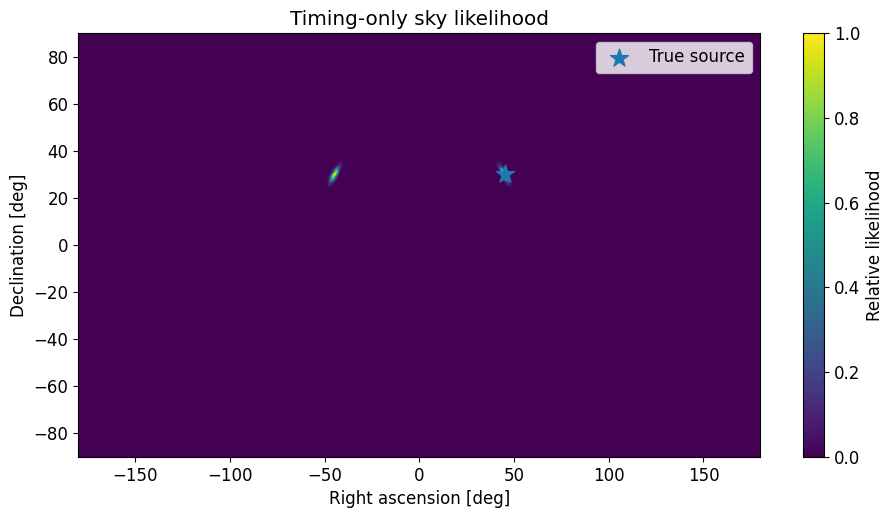

In [ ]:
chi2 = (resid1/sigma_dt)**2 + (resid2/sigma_dt)**2
logL = -0.5 * chi2
prob = np.exp(logL - np.max(logL))

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(prob, origin="lower",
               extent=[-180, 180, -90, 90],
               aspect="auto", interpolation="nearest")
ax.scatter(true_ra, true_dec, marker="*", s=180, label="True source")
ax.set_xlabel("Right ascension [deg]")
ax.set_ylabel("Declination [deg]")
ax.set_title("Timing-only sky likelihood")
ax.legend()
plt.colorbar(im, ax=ax, label="Relative likelihood")
plt.show()


## 7. From a sky map to a follow-up area

Astronomers often quote a **90% credible sky area** in square degrees.

A cell in an RA/Dec grid has solid angle

$
d\Omega=\cos\delta\,d\delta\,d\alpha.
$

Also,

$
1~{\rm sr}=\left(\frac{180}{\pi}\right)^2{\rm deg}^2.
$

We rank pixels by posterior density and find the smallest high-probability set containing 90% of the posterior mass.


Approximate 90% timing-only credible area: 49.7 deg^2


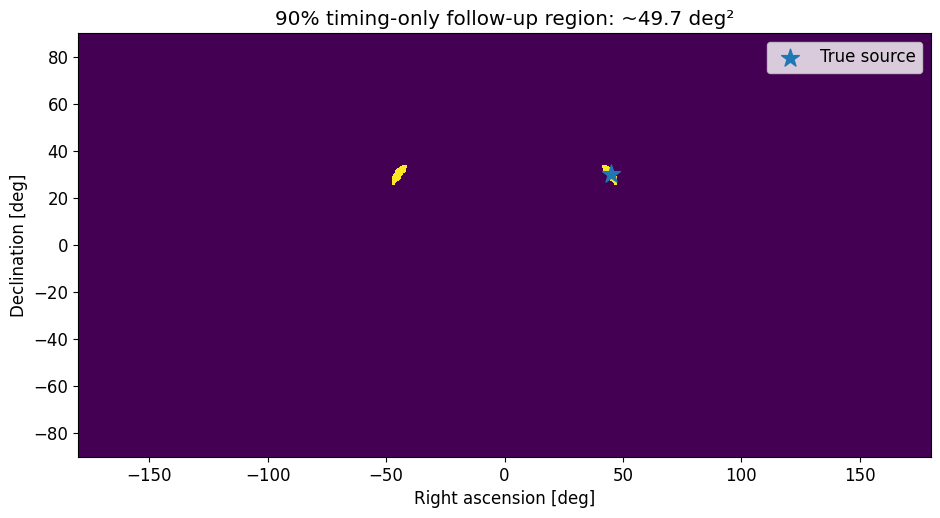

In [ ]:
def credible_region_mask(prob_density, RA, DEC, level=0.90):
    dra = np.deg2rad(abs(RA[0, 1] - RA[0, 0]))
    ddec = np.deg2rad(abs(DEC[1, 0] - DEC[0, 0]))
    cell_area_sr = np.cos(np.deg2rad(DEC)) * dra * ddec

    mass = prob_density * cell_area_sr
    mass /= mass.sum()

    density_flat = prob_density.ravel()
    mass_flat = mass.ravel()
    order = np.argsort(density_flat)[::-1]
    cumulative = np.cumsum(mass_flat[order])

    n_keep = np.searchsorted(cumulative, level) + 1
    chosen = order[:n_keep]

    mask_flat = np.zeros_like(density_flat, dtype=bool)
    mask_flat[chosen] = True
    mask = mask_flat.reshape(prob_density.shape)

    area_deg2 = cell_area_sr[mask].sum() * (180/np.pi)**2
    return mask, area_deg2

mask90, area90 = credible_region_mask(prob, RA, DEC, 0.90)

print(f"Approximate 90% timing-only credible area: {area90:.1f} deg^2")

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.imshow(mask90.astype(float), origin="lower",
          extent=[-180, 180, -90, 90],
          aspect="auto", interpolation="nearest")
ax.scatter(true_ra, true_dec, marker="*", s=180, label="True source")
ax.set_xlabel("Right ascension [deg]")
ax.set_ylabel("Declination [deg]")
ax.set_title(f"90% timing-only follow-up region: ~{area90:.1f} deg²")
ax.legend()
plt.show()


## 8. Where does SNR enter?

The triangulation equation itself contains no SNR:

$
\Delta t=-\frac{\mathbf B\cdot\hat{\mathbf n}}{c}.
$

SNR controls how accurately the arrival time can be measured:

$
\boxed{
\sigma_t\sim\frac{1}{2\pi\rho\sigma_f}.
}
$

Thus

$
\boxed{
\text{higher SNR}
\rightarrow
\text{better timing}
\rightarrow
\text{thinner annuli}
\rightarrow
\text{smaller intersection region}.
}
$

Bandwidth matters too: a broadband chirp can be timed more precisely than a nearly monochromatic signal at the same SNR.


In [ ]:
def timing_sigma(rho, sigma_f_hz):
    return 1.0 / (2*np.pi*rho*sigma_f_hz)

sigma_f = 100.0  # illustrative effective bandwidth, Hz
snrs = [5, 10, 20, 40]

for rho in snrs:
    sig = timing_sigma(rho, sigma_f)
    print(f"SNR {rho:2d}: sigma_t ~ {1e3*sig:.3f} ms")


SNR  5: sigma_t ~ 0.318 ms
SNR 10: sigma_t ~ 0.159 ms
SNR 20: sigma_t ~ 0.080 ms
SNR 40: sigma_t ~ 0.040 ms


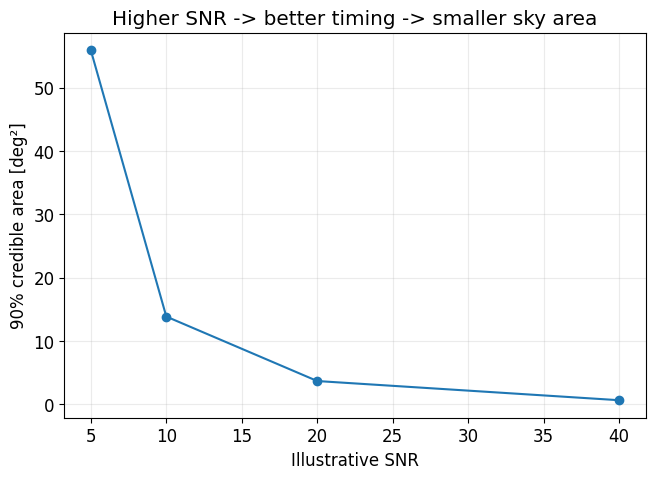

SNR  5: 90% area ~ 55.9 deg^2
SNR 10: 90% area ~ 13.9 deg^2
SNR 20: 90% area ~ 3.7 deg^2
SNR 40: 90% area ~ 0.6 deg^2


In [ ]:
areas = []

for rho in snrs:
    sig = timing_sigma(rho, sigma_f)
    chi2_rho = (resid1/sig)**2 + (resid2/sig)**2
    p = np.exp(-0.5*chi2_rho - np.max(-0.5*chi2_rho))
    _, area = credible_region_mask(p, RA, DEC, 0.90)
    areas.append(area)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(snrs, areas, marker="o")
ax.set_xlabel("Illustrative SNR")
ax.set_ylabel("90% credible area [deg²]")
ax.set_title("Higher SNR -> better timing -> smaller sky area")
ax.grid(alpha=0.25)
plt.show()

for rho, area in zip(snrs, areas):
    print(f"SNR {rho:2d}: 90% area ~ {area:.1f} deg^2")


## 9. Why do longer baselines help?

From

$
\Delta t=\frac{B}{c}\cos\theta,
$

we obtain

$
d(\Delta t)
=
-\frac{B}{c}\sin\theta\,d\theta.
$

Therefore

$
\boxed{
\sigma_\theta
\simeq
\frac{c\,\sigma_{\Delta t}}
{B|\sin\theta|}.
}
$

For fixed timing precision,

$
\boxed{\sigma_\theta\propto B^{-1}.}
$

Longer baselines make the timing annuli thinner.


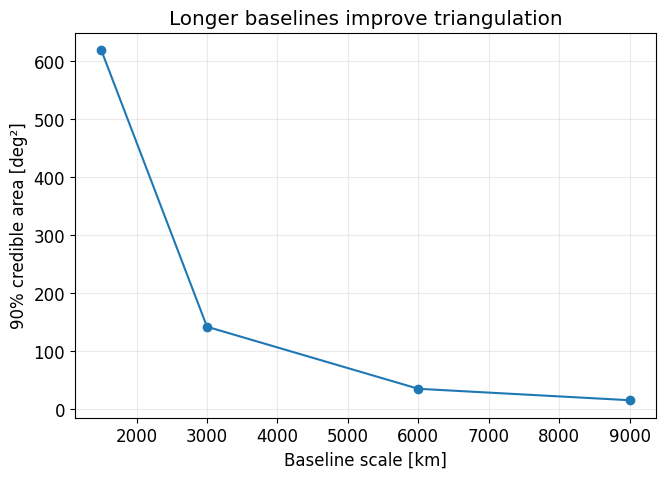

In [ ]:
baseline_lengths = [1500, 3000, 6000, 9000]  # km
areas_B = []

for B in baseline_lengths:
    b1 = np.array([0.0, 0.0, float(B)])
    b2 = np.array([float(B), 0.0, 0.0])

    r1 = time_delay(b1, N) - time_delay(b1, n_true)
    r2 = time_delay(b2, N) - time_delay(b2, n_true)

    chi2_B = (r1/sigma_dt)**2 + (r2/sigma_dt)**2
    pB = np.exp(-0.5*chi2_B - np.max(-0.5*chi2_B))
    _, areaB = credible_region_mask(pB, RA, DEC, 0.90)
    areas_B.append(areaB)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(baseline_lengths, areas_B, marker="o")
ax.set_xlabel("Baseline scale [km]")
ax.set_ylabel("90% credible area [deg²]")
ax.set_title("Longer baselines improve triangulation")
ax.grid(alpha=0.25)
plt.show()


## 10. Why does network geometry matter?

Two long baselines are less useful if they point almost in the same direction.

For baselines separated by angle \(\beta\),

$
|\mathbf B_1\times\mathbf B_2|
=
B_1B_2|\sin\beta|.
$

This equals twice the area of the triangle formed by the three detector sites.

Thus, schematically,

$
\boxed{
\text{long baselines}
+
\text{large network area}
\Rightarrow
\text{better triangulation}.
}
$

This is the real reason a geographically distributed network, including detectors in very different parts of the world, is so valuable.


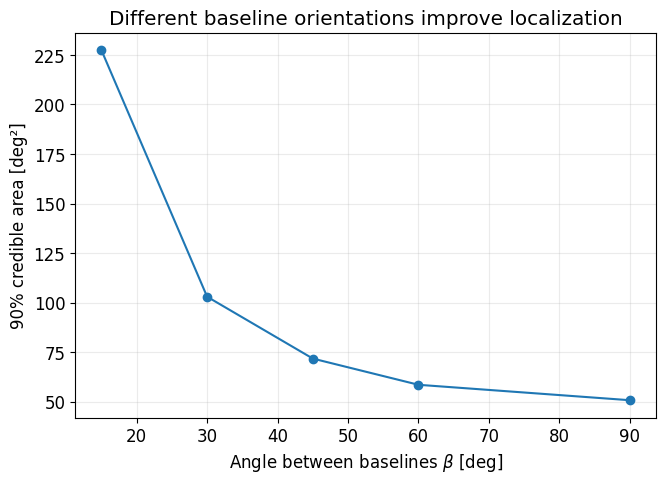

In [ ]:
B = 5000.0
betas = [15, 30, 45, 60, 90]
areas_beta = []

b1 = np.array([0.0, 0.0, B])

for beta_deg in betas:
    beta = np.deg2rad(beta_deg)
    b2 = B * np.array([np.sin(beta), 0.0, np.cos(beta)])

    r1 = time_delay(b1, N) - time_delay(b1, n_true)
    r2 = time_delay(b2, N) - time_delay(b2, n_true)

    chi2_beta = (r1/sigma_dt)**2 + (r2/sigma_dt)**2
    p_beta = np.exp(-0.5*chi2_beta - np.max(-0.5*chi2_beta))
    _, area_beta = credible_region_mask(p_beta, RA, DEC, 0.90)
    areas_beta.append(area_beta)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(betas, areas_beta, marker="o")
ax.set_xlabel(r"Angle between baselines $\beta$ [deg]")
ax.set_ylabel("90% credible area [deg²]")
ax.set_title("Different baseline orientations improve localization")
ax.grid(alpha=0.25)
plt.show()


## 11. H, L, and V: three pairwise baselines, but only two independent ones

For Hanford \(H\), Livingston \(L\), and Virgo \(V\),

$
\mathbf B_{HL},\qquad
\mathbf B_{HV},\qquad
\mathbf B_{LV}
$

can all be drawn. But

$
\boxed{
\mathbf B_{LV}
=
\mathbf B_{HV}-\mathbf B_{HL}.
}
$

Likewise,

$
\boxed{
\Delta t_{LV}
=
\Delta t_{HV}-\Delta t_{HL}.
}
$

Three arrival times contain one arbitrary common event time, leaving

$
3-1=2
$

independent time differences.

So:

$
\boxed{
2~\text{detectors}
\rightarrow
1~\text{independent delay}
\rightarrow
\text{annulus}
}
$

whereas

$
\boxed{
3~\text{detectors}
\rightarrow
2~\text{independent delays}
\rightarrow
\text{intersecting annuli}.
}
$


## 12. From triangulation to a real GW sky map

This notebook used **timing only**. Real localization also uses:

- **relative amplitudes** between detectors,
- **relative phases**,
- the detector antenna patterns $F_+$ and $F_\times$,
- correlations with source inclination, polarization, distance, masses, spins, and phase.

Each detector measures

$
h_I
=
F_+^I(\alpha,\delta,\psi)h_+
+
F_\times^I(\alpha,\delta,\psi)h_\times.
$

Therefore the conceptual progression is

$
\boxed{
\text{arrival times}
\rightarrow
\text{timing annuli}
\rightarrow
\text{annulus intersections}
\rightarrow
\text{amplitude + phase + antenna response}
\rightarrow
\text{final sky posterior}.
}
$

The final posterior is converted into a credible region -- often the **90% sky area** -- that telescopes can use for electromagnetic follow-up.


# Exercises

### Exercise 1: Move the source
Change `true_ra` and `true_dec`, then rerun the notebook. How do the annuli and mirror patches move?

### Exercise 2: Make the timing worse
Change

```python
sigma_dt = 1.0e-3
```

How does the 90% area change?

### Exercise 3: Shorten the baseline
Reduce one baseline from \(8250\) km to \(1000\) km. Explain the result using

$
\sigma_\theta\simeq\frac{c\sigma_{\Delta t}}{B|\sin\theta|}.
$

### Exercise 4: Nearly parallel baselines
Set the angle between the baselines to \(5^\circ\). Why is localization poor even though there are still two delays?

### Exercise 5: SNR and bandwidth
Use

$
\sigma_t\simeq\frac{1}{2\pi\rho\sigma_f}
$

to compare:

- $\rho=10,\ \sigma_f=50\,\mathrm{Hz}$
- $\rho=20,\ \sigma_f=50\,\mathrm{Hz}$
- $\rho=10,\ \sigma_f=150\,\mathrm{Hz}$

Which signal is timed most precisely?

### Exercise 6: Challenge
How would you adapt this notebook to reproduce the skymaps for GW170817? You would need:

1. The $B_{ij}$ vectors for each IFO pair
2. Their SNRs / frequency spread, which maps to the uncertainty in times
3. Rotate the detector coordinates into the celestial frame at 2017-08-17 12:41:04 UTC


# Take-home message

The geometric core is

$
\boxed{
\Delta t_{ij}
=
-\frac{\mathbf B_{ij}\cdot\hat{\mathbf n}}{c}.
}
$

Then

$
\boxed{
\text{one baseline}
\rightarrow
\text{one timing annulus}
}
$

and

$
\boxed{
\text{second independent baseline}
\rightarrow
\text{annulus intersections}.
}
$

Finally,

$
\boxed{
\text{higher SNR and larger bandwidth}
\rightarrow
\text{better timing}
\rightarrow
\text{thinner annuli},
}
$

while

$
\boxed{
\text{longer, differently oriented baselines}
\rightarrow
\text{smaller sky-localization area}.
}
$
